**Step 1. 이것만큼은 꼭 해보세요!**

프로젝트에 정답은 없습니다. 배우신 내용을 토대로 자유롭게 데이터를 정제하고 변환하되, 아래 내용만큼은 반드시 실습해봅시다.

**Step 2. 이런것도 해볼 수 있어요!**

자유롭게 실습을 해보시고, 여유가 되면 아래의 내용도 실습해보세요.

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
car_df = pd.read_csv('cars.csv')

In [15]:
brand_df = pd.read_csv('brand.csv')

In [16]:
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [17]:
brand_df.head()

,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


In [18]:
car_df.isna().sum()

title                   0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners      1411
Fuel type               0
Body type               0
Engine                 45
Gearbox                 0
Doors                  25
Seats                  35
Emission Class         87
Service history      3147
dtype: int64

In [19]:
car_df.columns.tolist()

['title',
 'Price',
 'Mileage(miles)',
 'Registration_Year',
 'Previous Owners',
 'Fuel type',
 'Body type',
 'Engine',
 'Gearbox',
 'Doors',
 'Seats',
 'Emission Class',
 'Service history']

cars.csv와 brand.csv의 데이터 합치기

- [힌트] cars.csv의 title 변수로부터 브랜드 데이터를 추출할 수 있습니다.

In [20]:
car_df['car_brand'] = car_df['title'].str.split().str[0]
car_df['car_name'] = car_df['title'].str.split().str[1:].str.join(" ")

In [21]:
car_df['car_brand'] = car_df['car_brand'].str.strip().str.lower()

In [26]:
# brand_df와 merge
car_df = car_df.merge(
    brand_df.rename(columns={'title': 'car_brand'}),
    on='car_brand',
    how='left'
)

In [22]:
car_df['car_brand']

0          skoda
1       vauxhall
2        hyundai
3           mini
4       vauxhall
          ...   
3682     renault
3683        audi
3684         bmw
3685       honda
3686    vauxhall
Name: car_brand, Length: 3687, dtype: object

In [23]:
car_df

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,car_brand,car_name
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda,FABIA
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall,CORSA
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai,I30
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini,HATCH
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall,CORSA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,renault,MEGANE
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,audi,A4
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,bmw,3 SERIES
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,honda,ACCORD


카테고리형 변수를 숫자 형태로 변환하기

- [힌트] Engine, Emission Class 변수에 주목하세요!

In [29]:
car_df['Engine'].unique()

array(['1.4L', '1.2L', '1.3L', '2.0L', '1.6L', '2.3L', '1.8L', '1.0L',
       '3.0L', '1.5L', '1.9L', '2.4L', '2.2L', '3.5L', '3.2L', '2.5L',
       '1.1L', '3.1L', '3.7L', '2.6L', '2.1L', '2.8L', '5.0L', '0.8L',
       '2.7L', '1.7L', '0.9L', '4.2L', nan, '4.4L', '4.3L', '3.3L',
       '5.5L', '4.8L', '6.3L'], dtype=object)

In [30]:
car_df['Emission Class'].unique()

array(['Euro 6', 'Euro 4', 'Euro 5', nan, 'Euro 3', 'Euro 2', 'Euro 1'],
      dtype=object)

In [31]:
car_df['Engine'] = car_df['Engine'].str.replace('L', '').astype(float)
car_df['Emission Class'] = car_df['Emission Class'].str.replace('Euro ', '').astype(float)

결측치 처리하기

- [힌트] Service history 변수의 결측치는 'Unknown'으로 채우고, 결측치 변수가 일정 개수 이상 포함된 데이터는 제거합니다.

In [32]:
car_df['Service history'] = car_df['Service history'].fillna('Unknown')
car_df.isna().sum(axis=1).value_counts()

0    2239
1    1368
3      48
2      19
4      12
5       1
Name: count, dtype: int64

In [33]:
car_df = car_df.dropna(thresh=len(car_df.columns) - 1)
car_df.isna().sum(axis=1).value_counts()

0    2239
1    1368
Name: count, dtype: int64

Scaler 활용해보기

- 기존 데이터의 정보 70% 이상을 가지는 수준에서 최소한의 주성분 추출 (PCA)

In [34]:
car_df.dtypes

title                 object
Price                  int64
Mileage(miles)         int64
Registration_Year      int64
Previous Owners      float64
Fuel type             object
Body type             object
Engine               float64
Gearbox               object
Doors                float64
Seats                float64
Emission Class       float64
Service history       object
car_brand             object
car_name              object
country_x             object
country_y             object
dtype: object

In [39]:
# 수치형 컬럼만 추출
num_cols = ['Price', 'Mileage(miles)', 'Registration_Year', 'Previous Owners', 
            'Engine', 'Doors', 'Seats', 'Emission Class']

num_df = car_df[num_cols].dropna()

# 1. Scaling
scaler = StandardScaler()
scaled = scaler.fit_transform(num_df)

In [40]:
pca = PCA(n_components=0.7)
pca_result = pca.fit_transform(scaled)

print(f"원래 변수 개수: {len(num_cols)}")
print(f"PCA 후 변수 개수: {pca_result.shape[1]}")
print(f"설명된 분산 비율: {sum(pca.explained_variance_ratio_):.2%}")

원래 변수 개수: 8
PCA 후 변수 개수: 3
설명된 분산 비율: 74.30%


시각화

C:\Users\user\AppData\Local\Temp\ipykernel_1304\1504727101.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=fuel_types)


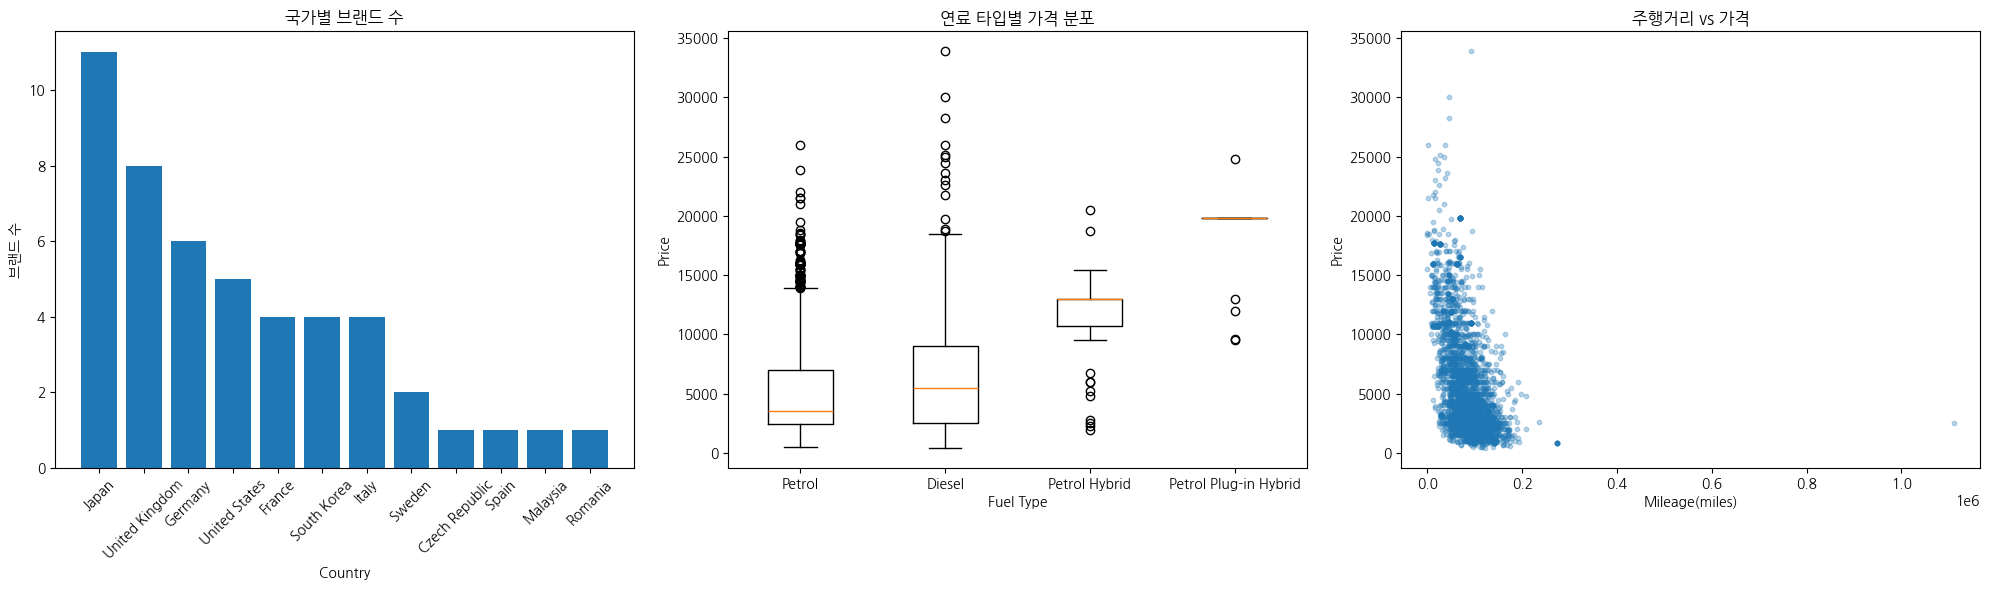

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 국가별 브랜드 수
country_counts = brand_df['country'].value_counts()
axes[0].bar(country_counts.index, country_counts.values)
axes[0].set_title('국가별 브랜드 수')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('브랜드 수')
axes[0].tick_params(axis='x', rotation=45)

# 2. 연료 타입별 가격 분포
fuel_types = car_df['Fuel type'].value_counts().index[:4]  # 상위 4개만
data = [car_df[car_df['Fuel type'] == f]['Price'].dropna() for f in fuel_types]
axes[1].boxplot(data, labels=fuel_types)
axes[1].set_title('연료 타입별 가격 분포')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Price')

# 3. 주행거리 vs 가격
axes[2].scatter(car_df['Mileage(miles)'], car_df['Price'], alpha=0.3, s=10)
axes[2].set_title('주행거리 vs 가격')
axes[2].set_xlabel('Mileage(miles)')
axes[2].set_ylabel('Price')

plt.tight_layout()
plt.show()